# 07 — Charge d'entraînement : TRIMP, ATL/CTL/TSB

Le modèle de charge d'entraînement quantifie l'**état de forme** en séparant :
- **CTL** (Chronic Training Load, τ=42 j) — la forme de fond (fitness)
- **ATL** (Acute Training Load, τ=7 j) — la fatigue récente
- **TSB** (Training Stress Balance) = CTL − ATL — la fraîcheur

**TRIMP (Training Impulse) :**
```
TRIMP = durée_min × (1 − readiness / 100)
```
Un athlète très récupéré (readiness=90) génère un faible TRIMP pour la même durée.
Un athlète fatigué (readiness=40) génère un TRIMP élevé → plus de stress.

**Zones TSB :**
| TSB | Zone | Recommandation |
|---|---|---|
| > +25 | Désentraînement | Augmenter la charge |
| +5 à +25 | Frais | Session intense possible |
| −10 à +5 | Optimal | Maintenir |
| < −10 | Fatigué | Récupération prioritaire |

In [1]:
from pathlib import Path

from dotenv import load_dotenv

load_dotenv(Path("../.env"))

import matplotlib.pyplot as plt

from cardiolab.analytics.training_load import (
    TrainingLoad,
    trimp_banister,
    trimp_hrv_based,
)
from cardiolab.database import HRVRepository
from cardiolab.labels import LABELS_FR
from cardiolab.reporting import summary_training_load, table_training_load_history
from cardiolab.visualization.training_load_plots import (
    plot_atl_ctl_tsb,
    plot_trimp_history,
    plot_tsb_zones,
)

USER_ID_TEST = "demo-user"
print("✓  OK")

✓  OK


## 1 — Calculer le TRIMP d'une session

Deux méthodes disponibles :
- `trimp_hrv_based` — utilise le score de readiness HRV (précis, nécessite mesure HRV)
- `trimp_banister` — utilise les données HR de l'effort (capteur d'effort, sans HRV)

In [2]:
# Exemples de calcul TRIMP
duration = 60.0  # minutes

# Méthode HRV-based
readiness_good = 72.0  # bonne récupération
readiness_tired = 35.0  # fatigue élevée

t_good = trimp_hrv_based(duration, readiness_good)
t_tired = trimp_hrv_based(duration, readiness_tired)

print("TRIMP HRV-based (60 min) :")
print(f"  Readiness 72 (bonne récup.) : TRIMP = {t_good:.1f}")
print(f"  Readiness 35 (fatigué)      : TRIMP = {t_tired:.1f}")
print(f"  → Même durée, mais {t_tired / t_good:.1f}× plus de stress quand fatigué")

# Méthode Banister (avec capteur HR)
t_ban = trimp_banister(duration, hr_mean=148, hr_max=185, hr_rest=55, sex="male")
print(f"\nTRIMP Banister (60 min, HR 148/185/55, homme) : {t_ban:.1f}")

TRIMP HRV-based (60 min) :
  Readiness 72 (bonne récup.) : TRIMP = 16.8
  Readiness 35 (fatigué)      : TRIMP = 39.0
  → Même durée, mais 2.3× plus de stress quand fatigué

TRIMP Banister (60 min, HR 148/185/55, homme) : 169.5


## 2 — Enregistrer des sessions d'entraînement

Chaque activité est une ligne distincte en base (`activity_id` UUID unique).
Plusieurs activités le même jour sont supportées — les barres TRIMP sont empilées.

In [3]:
sessions_demo = [
    {"date": "2026-04-24", "duration_min": 45.0, "sport": "running", "trimp": 38.5},
    {"date": "2026-04-25", "duration_min": 30.0, "sport": "strength", "trimp": 18.0},
    {"date": "2026-04-26", "duration_min": 0.0, "sport": None, "trimp": None},  # repos
    {"date": "2026-04-27", "duration_min": 60.0, "sport": "cycling", "trimp": 52.0},
    {
        "date": "2026-04-27",
        "duration_min": 20.0,
        "sport": "strength",
        "trimp": 12.0,
    },  # 2 activités
    {"date": "2026-04-28", "duration_min": 50.0, "sport": "running", "trimp": 42.0},
    {"date": "2026-04-29", "duration_min": 30.0, "sport": "swimming", "trimp": 28.0},
    {"date": "2026-04-30", "duration_min": 0.0, "sport": None, "trimp": None},  # repos
]

with HRVRepository.from_env() as repo:
    for s in sessions_demo:
        if s["trimp"] is not None:
            aid = repo.save_training_session(
                user_id=USER_ID_TEST,
                date=s["date"],
                duration_min=s["duration_min"],
                sport_type=s["sport"],
                trimp=s["trimp"],
            )
            print(
                f"  ✓  {s['date']}  {s['sport']:<10}  "
                f"{s['duration_min']:5.0f} min  TRIMP={s['trimp']:5.1f}"
            )

print("\n✅  Sessions enregistrées")

  ✓  2026-04-24  running        45 min  TRIMP= 38.5
  ✓  2026-04-25  strength       30 min  TRIMP= 18.0
  ✓  2026-04-27  cycling        60 min  TRIMP= 52.0
  ✓  2026-04-27  strength       20 min  TRIMP= 12.0
  ✓  2026-04-28  running        50 min  TRIMP= 42.0
  ✓  2026-04-29  swimming       30 min  TRIMP= 28.0

✅  Sessions enregistrées


## 3 — Construire le modèle ATL/CTL/TSB

In [4]:
with HRVRepository.from_env() as repo:
    sessions = repo.load_training_sessions(USER_ID_TEST)

tl = TrainingLoad.from_sessions(sessions)

summary = summary_training_load(tl)
print("Résumé actuel :")
print(f"  ATL (fatigue récente)  : {summary['atl']:.1f}")
print(f"  CTL (forme de fond)    : {summary['ctl']:.1f}")
print(f"  TSB (fraîcheur)        : {summary['tsb']:+.1f}")
print(f"  Zone TSB               : {summary['tsb_zone']}")
print(f"  Tendance CTL           : {summary['ctl_trend']}")

Résumé actuel :
  ATL (fatigue récente)  : 18.8
  CTL (forme de fond)    : 4.2
  TSB (fraîcheur)        : -14.6
  Zone TSB               : accumulated_fatigue
  Tendance CTL           : stable


## 4 — Visualisations

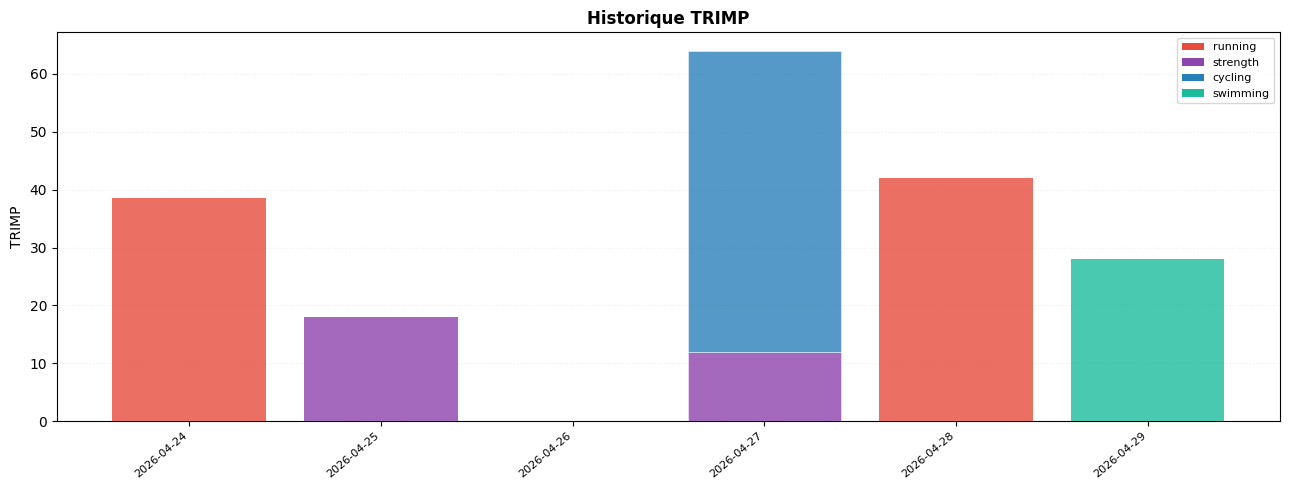

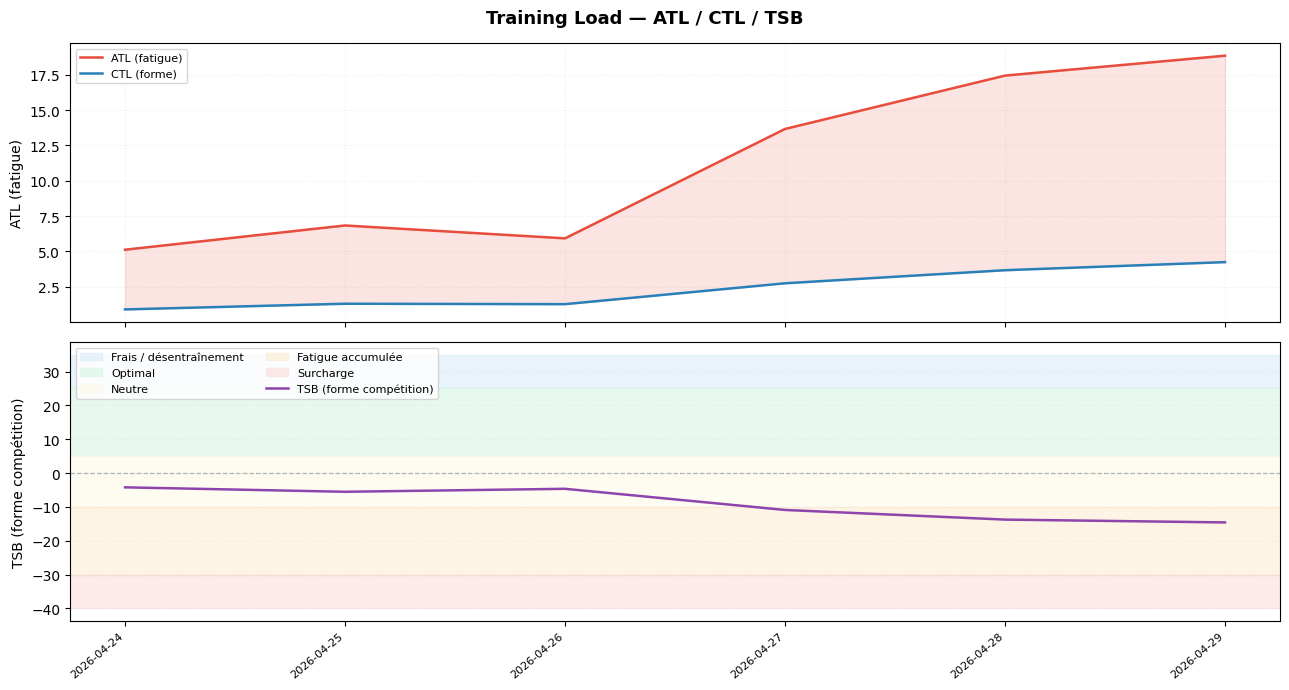

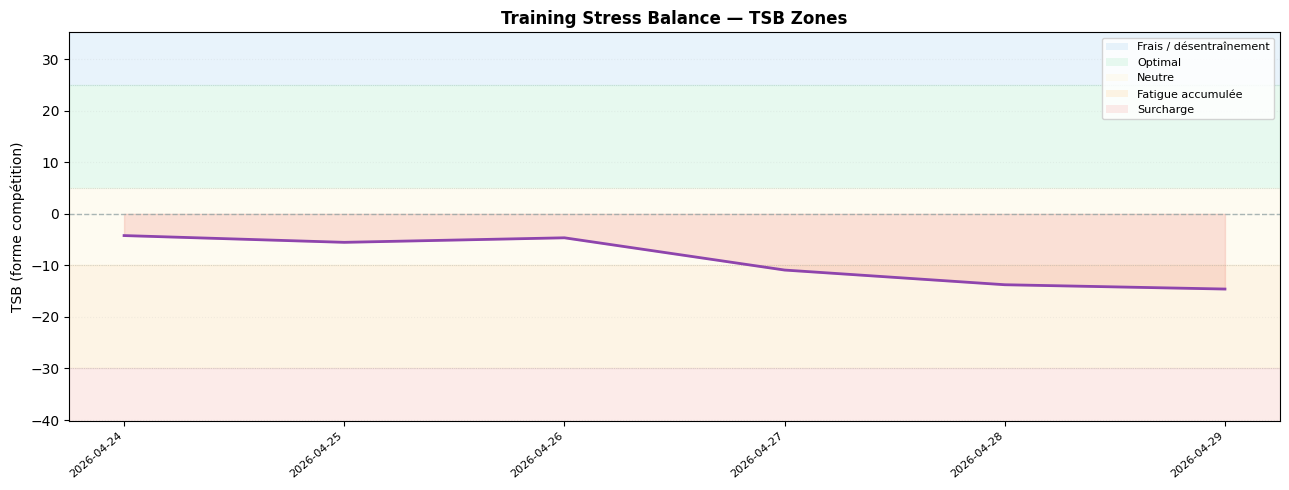

In [5]:
# TRIMP history — barres empilées pour les jours multi-activités
fig = plot_trimp_history(
    tl, sessions=sessions, labels=LABELS_FR, title="Historique TRIMP"
)
plt.show()

# ATL / CTL / TSB
fig = plot_atl_ctl_tsb(tl, labels=LABELS_FR)
plt.show()

# Zones TSB
fig = plot_tsb_zones(tl, labels=LABELS_FR)
plt.show()

## 5 — Tableau de charge

In [6]:
styler = table_training_load_history(tl, labels=LABELS_FR)
display(styler)

,Date,TRIMP,ATL (fatigue),CTL (forme),TSB (forme compétition),tsb_zone
0,2026-04-24,38.5,5.13,0.91,-4.22,neutral
1,2026-04-25,18.0,6.84,1.31,-5.53,neutral
2,2026-04-26,0.0,5.93,1.28,-4.65,neutral
3,2026-04-27,64.0,13.66,2.75,-10.91,accumulated_fatigue
4,2026-04-28,42.0,17.43,3.68,-13.76,accumulated_fatigue
5,2026-04-29,28.0,18.84,4.25,-14.59,accumulated_fatigue
